<a href="https://colab.research.google.com/github/Evgenii1994/DLS2/blob/main/week_03_language_modeling/Homework/hw_language_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [ ]:
!pip install datasets==3.4.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 16.5 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 3.3.1
    Uninstalling datasets-3.3.1:
      Successfully uninstalled datasets-3.3.1


Импорт необходимых библиотек

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [ ]:
# Загрузим датасет
dataset = load_dataset('imdb')

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [ ]:
word_threshold = 32

sentences = [sent for text in tqdm(dataset['train']['text'], desc="Tokenizing sentences") for sent in nltk.sent_tokenize(text)]
sentences = [sent for sent in tqdm(sentences, desc="Filtering sentences") if len(nltk.word_tokenize(sent)) < word_threshold]

print("Всего предложений:", len(sentences))

Tokenizing sentences:   0%|          | 0/25000 [00:00<?, ?it/s]

Filtering sentences:   0%|          | 0/270853 [00:00<?, ?it/s]

Всего предложений: 198756


Посчитаем для каждого слова его встречаемость.
Выведем топ 10.

In [ ]:
word_counts = Counter(word for sent in tqdm(sentences, desc="Counting words") for word in nltk.word_tokenize(sent))
word_counts.most_common(10)

Counting words:   0%|          | 0/198756 [00:00<?, ?it/s]

[('.', 170550),
 ('the', 126251),
 (',', 114297),
 ('a', 71707),
 ('and', 68658),
 ('of', 62132),
 ('to', 59700),
 ('is', 56734),
 ('I', 46465),
 ('it', 39518)]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [ ]:
vocab = set()
vocab_size = 40000

most_common_words = {word for word, _ in word_counts.most_common(vocab_size)}
vocab = {'<unk>', '<bos>', '<eos>', '<pad>'}.union(most_common_words)

In [ ]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [ ]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


Завернем в функцию:

In [ ]:
import nltk
from collections import Counter
from tqdm import tqdm


def preprocess_data(texts, word_threshold=32, vocab_size=40000):
    sentences = [sent for text in tqdm(texts, desc="Tokenizing sentences") for sent in nltk.sent_tokenize(text)]
    filtered_sentences = [sent for sent in tqdm(sentences, desc="Filtering sentences") if len(nltk.word_tokenize(sent)) < word_threshold]

    word_counts = Counter(word for sent in tqdm(filtered_sentences, desc="Counting words") for word in nltk.word_tokenize(sent))
    most_common_words = {word for word, _ in word_counts.most_common(vocab_size)}

    vocab = {'<unk>', '<bos>', '<eos>', '<pad>'}.union(most_common_words)
    return vocab, sentences


In [ ]:
vocab, sentences = preprocess_data(dataset['train']['text'], word_threshold=32, vocab_size=40000)

Counting words: 100%|██████████| 198756/198756 [00:23<00:00, 8629.05it/s]


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [ ]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [ ]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokens = nltk.word_tokenize(self.data[idx])
        tokenized_sentence = [self.bos_id] + [word2ind.get(token, self.unk_id) for token in tokens] + [self.eos_id]
        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [ ]:
def collate_fn_with_padding(input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = [
        sequence + [pad_id] * (max_seq_len - len(sequence))
        for sequence in input_batch
    ]

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:, :-1],
        'target_ids': sequences[:, 1:]
    }

    return new_batch

In [ ]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(eval_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 24

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size, drop_last=True)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size, drop_last=True)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size, drop_last=True)


## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [ ]:
from tqdm import tqdm

def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    return sum(perplexity) / len(perplexity)


### Train loop (1 балл)

Напишите функцию для обучения модели.

Реализован learning rate scheduler с warmup на 5% шагов обучения.

Реализован reduce on plato.

Реализована аккумуляция градиента, т к батч достаточно небольшой.

Реализован ранний останов при отсутствии улучшений.

In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_lr_lambda(warmup_steps, total_steps):
    """Функция для управления learning rate."""
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))  # Linear warmup
        return float(total_steps - current_step) / float(max(1, total_steps - warmup_steps))
    return lr_lambda

def train_model(
    model, train_dataloader, val_dataloader, criterion, optimizer, epochs,
    device, patience=3, grad_accumulation_steps=4,
):
    model.to(device)

    train_losses = []
    val_losses = []
    perplexities = []

    total_steps = epochs * len(train_dataloader) // grad_accumulation_steps
    warmup_steps = int(0.05 * total_steps)

    warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(warmup_steps, total_steps))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True, min_lr=1e-6)

    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        optimizer.zero_grad()

        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

        for step, batch in enumerate(progress_bar):
            logits = model(batch['input_ids'])
            logits = logits.reshape(-1, logits.size(-1))
            target_ids = batch['target_ids'].reshape(-1)

            loss = criterion(logits, target_ids)
            loss = loss / grad_accumulation_steps
            loss.backward()

            if (step + 1) % grad_accumulation_steps == 0 or (step + 1 == len(train_dataloader)):
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
                optimizer.step()
                warmup_scheduler.step()
                optimizer.zero_grad()

            total_loss += loss.item() * grad_accumulation_steps
            progress_bar.set_postfix({"Loss": loss.item() * grad_accumulation_steps, "LR": optimizer.param_groups[0]["lr"]})

        avg_train_loss = total_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_dataloader:
                logits = model(batch['input_ids'])
                logits = logits.reshape(-1, logits.size(-1))
                target_ids = batch['target_ids'].reshape(-1)

                loss = criterion(logits, target_ids)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)

        perplexity = evaluate(model, criterion, val_dataloader)
        perplexities.append(perplexity)

        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0  # Reset counter
            best_model_state = model.state_dict()  # Save best model
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Perplexity: {perplexity:.4f} | LR: {current_lr:.6f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            if best_model_state:
                model.load_state_dict(best_model_state)  # Restore best model
            break

    return train_losses, val_losses, perplexities


### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

Реализована базовая, достаточно простая архитектура, несколько рекурентных слоев + несколько полносвязных слоев.

Будем от нее отталкиваться.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class LanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=1, rnn_type='LSTM', dropout=0.3, num_linear_layers=1, activation_fn='ReLU'):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        rnn_cls = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)

        linear_layers = []
        for _ in range(num_linear_layers - 1):
            linear_layers.append(nn.Linear(hidden_dim, hidden_dim))
            linear_layers.append(getattr(nn, activation_fn)())
            linear_layers.append(nn.Dropout(dropout))

        linear_layers.append(nn.Linear(hidden_dim, vocab_size))
        self.fc = nn.Sequential(*linear_layers)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_batch)
        rnn_out, _ = self.rnn(embedded)
        output = self.fc(rnn_out)
        return output


Функция для отображения графиков лосса и перплексити.

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_and_perplexity(train_losses, val_losses, perplexities):
    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

    # Loss Plot
    axes[0].plot(epochs, train_losses, 'r-', label="Train Loss")
    axes[0].plot(epochs, val_losses, 'r--', label="Validation Loss")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Train & Validation Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Perplexity Plot
    axes[1].plot(epochs, perplexities, 'b-', label="Perplexity")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Perplexity")
    axes[1].set_title("Perplexity Over Epochs")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


Функция для генерации текстовой последовательности.

In [ ]:
import torch

def generate_sequence(model, starting_seq: str, max_seq_len: int = 128) -> str:
    device = next(model.parameters()).device  # Get model's device
    model.eval()

    input_ids = [word2ind['<bos>']] + [
        word2ind.get(word, word2ind['<unk>']) for word in starting_seq.split()
    ]
    input_ids = torch.tensor(input_ids, dtype=torch.long, device=device)

    with torch.no_grad():
        for _ in range(max_seq_len):
            logits = model(input_ids.unsqueeze(0))  # Add batch dimension
            next_word_distribution = logits[:, -1, :]  # Last time step
            next_word = next_word_distribution.argmax(dim=-1)

            input_ids = torch.cat([input_ids, next_word])  # Append token

            if next_word.item() == word2ind['<eos>']:
                break

    generated_text = ' '.join([ind2word[idx.item()] for idx in input_ids])

    return generated_text


Функция для поиска оптимального значения learning rate.

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def lr_finder(model, train_dataloader, criterion, optimizer, device, init_lr=1e-7, final_lr=10, num_iter=100):
    model.train()
    model.to(device)

    mult = (final_lr / init_lr) ** (1 / num_iter)
    lr = init_lr

    for param_group in optimizer.param_groups:
        param_group["lr"] = lr

    losses = []
    lrs = []
    best_loss = float("inf")
    step = 0

    for batch in train_dataloader:
        batch = {key: value.to(device) for key, value in batch.items()}

        logits = model(batch['input_ids'])
        logits = logits.reshape(-1, logits.size(-1))
        target_ids = batch['target_ids'].reshape(-1)

        loss = criterion(logits, target_ids)

        losses.append(loss.item())
        lrs.append(lr)

        if loss.item() > best_loss * 3:
            break

        best_loss = min(best_loss, loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lr *= mult
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        step += 1
        if step >= num_iter:
            break

    return lrs, losses

def plot_lr_finder(lrs, losses):
    """Plots LR Finder results to identify optimal LR range."""
    plt.figure(figsize=(8, 5))
    plt.plot(lrs, losses)
    plt.xscale("log")
    plt.xlabel("Learning Rate (log scale)")
    plt.ylabel("Loss")
    plt.title("Learning Rate Finder")
    plt.grid(True)
    plt.show()


In [ ]:
model = LanguageModel(
    vocab_size=len(word2ind),
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    rnn_type='LSTM',
    dropout=0.3,
    num_linear_layers=2,
    activation_fn='ReLU',
    )
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-7)

lrs, losses = lr_finder(model, train_dataloader, criterion, optimizer, device)

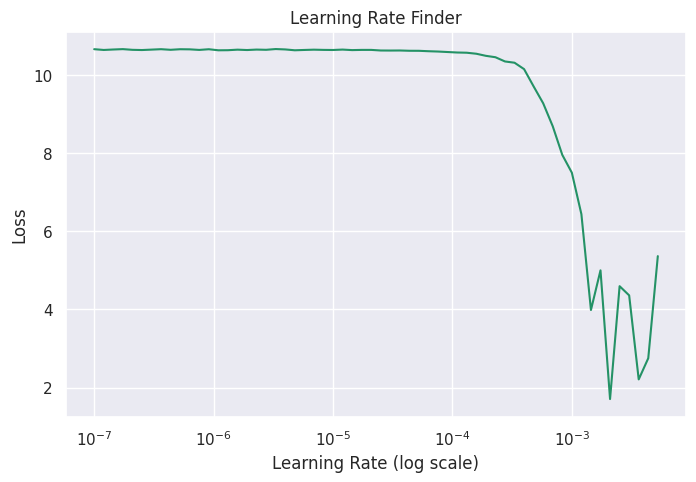

In [ ]:
plot_lr_finder(lrs, losses)

По графику выше делаем вывод что 3e-3 или 2e-3 будет неплохим выбором.

In [ ]:
epochs = 10
learning_rate = 3e-3

In [ ]:
model = LanguageModel(
    vocab_size=len(word2ind),
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    rnn_type='LSTM',
    dropout=0.3,
    num_linear_layers=2,
    activation_fn='ReLU',
    )
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses, perplexities = train_model(
    model, train_dataloader, eval_dataloader, criterion, optimizer, epochs, device, patience=2, grad_accumulation_steps=4
)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/10 | Train Loss: 2.0712 | Val Loss: 1.6115 | Perplexity: 5.5580 | LR: 0.002842


Epoch 2/10 | Train Loss: 1.6027 | Val Loss: 1.5294 | Perplexity: 5.0674 | LR: 0.002526


Epoch 3/10 | Train Loss: 1.5350 | Val Loss: 1.4943 | Perplexity: 4.8712 | LR: 0.002210


Epoch 4/10 | Train Loss: 1.4938 | Val Loss: 1.4757 | Perplexity: 4.7718 | LR: 0.001895


...

Epoch 6/10 | Train Loss: 1.4416 | Val Loss: 1.4620 | Perplexity: 4.6993 | LR: 0.001263


Epoch 7/10 | Train Loss: 1.4235 | Val Loss: 1.4602 | Perplexity: 4.6905 | LR: 0.000947


Epoch 8/10 | Train Loss: 1.4089 | Val Loss: 1.4582 | Perplexity: 4.6803 | LR: 0.000631


Epoch 9/10 | Train Loss: 1.3970 | Val Loss: 1.4562 | Perplexity: 4.6698 | LR: 0.000315


Epoch 10/10 | Train Loss: 1.3885 | Val Loss: 1.4562 | Perplexity: 4.6700 | LR: -0.000000


Видим что обучение стабильное.

Обучение можно не продолжать т к значение лосса на валидации перестало значительно изменяться.

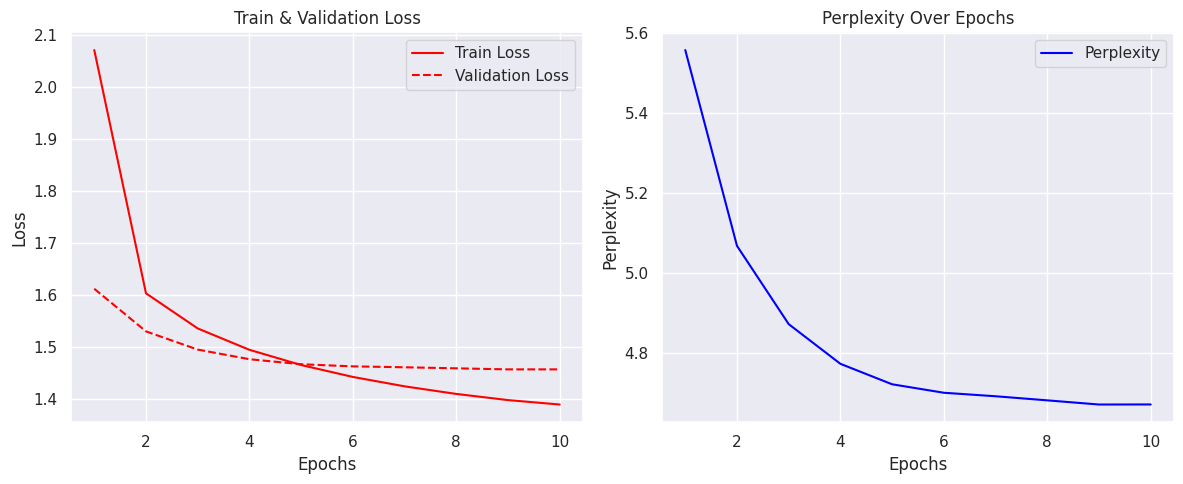

In [ ]:
plot_loss_and_perplexity(train_losses, val_losses, perplexities)

Посмотрим на качество на тесте и сравним с валидацией.

In [ ]:
val_ppl = evaluate(model, criterion, eval_dataloader)
test_ppl = evaluate(model, criterion, test_dataloader)
print(f"\nPerplexity:\n Val: {val_ppl:.2f} Test: {test_ppl:.2f}")


Perplexity:
 Val: 4.67 Test: 4.68


Сгенерируем несколько последовательностей.

In [ ]:
print(generate_sequence(model, "This movie was absolutely"))
print(generate_sequence(model, "I couldn't believe how bad"))
print(generate_sequence(model, "The film had some great moments but"))

<bos> This movie was absolutely awful . <eos>
<bos> I <unk> believe how bad this movie is . <eos>
<bos> The film had some great moments but it was n't even funny . <eos>


### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

Попробуем добавить слой attention.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim, bias=False)
        nn.init.xavier_uniform_(self.attn.weight)

    def forward(self, rnn_out):
        attn_weights = torch.softmax(self.attn(rnn_out), dim=1)
        context = attn_weights * rnn_out
        return context

class LanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=1, rnn_type='LSTM',
                 dropout=0.5, num_linear_layers=1, activation_fn='ReLU', use_attention=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        rnn_cls = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)

        self.use_attention = use_attention
        if use_attention:
            self.attention = Attention(hidden_dim)

        linear_layers = []
        for _ in range(num_linear_layers - 1):
            linear_layers.append(nn.Linear(hidden_dim, hidden_dim))
            linear_layers.append(getattr(nn, activation_fn)())
            linear_layers.append(nn.Dropout(dropout))

        linear_layers.append(nn.Linear(hidden_dim, vocab_size))
        self.fc = nn.Sequential(*linear_layers)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_batch)
        rnn_out, _ = self.rnn(embedded)

        if self.use_attention:
            context = self.attention(rnn_out)
            output = self.fc(self.dropout(context))
        else:
            output = self.fc(self.dropout(rnn_out))

        return output

In [ ]:
model = LanguageModel(
    vocab_size=len(word2ind),
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    rnn_type='LSTM',
    dropout=0.3,
    num_linear_layers=2,
    activation_fn='Tanh',
    use_attention=True,
    )
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-7)

lrs, losses = lr_finder(model, train_dataloader, criterion, optimizer, device)

Подбираем оптимальные параметры learning rate.

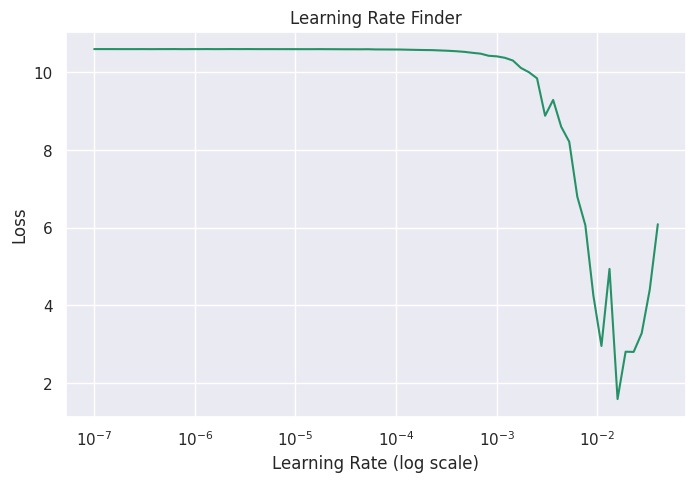

In [ ]:
plot_lr_finder(lrs, losses)

In [ ]:
epochs = 15
learning_rate = 2e-2

In [ ]:
model = LanguageModel(
    vocab_size=len(word2ind),
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    rnn_type='LSTM',
    dropout=0.3,
    num_linear_layers=2,
    activation_fn='Tanh',
    use_attention=True,
    )
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses, perplexities = train_model(
    model, train_dataloader, eval_dataloader, criterion, optimizer, epochs, device, patience=2, grad_accumulation_steps=4
)

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/15 | Train Loss: 2.0158 | Val Loss: 1.3555 | Perplexity: 4.1255 | LR: 0.019649


Epoch 2/15 | Train Loss: 1.4368 | Val Loss: 1.2504 | Perplexity: 3.6759 | LR: 0.018245


Epoch 3/15 | Train Loss: 1.3689 | Val Loss: 1.2051 | Perplexity: 3.4991 | LR: 0.016842


Epoch 4/15 | Train Loss: 1.3249 | Val Loss: 1.1757 | Perplexity: 3.3897 | LR: 0.015438


...

Epoch 10/15 | Train Loss: 1.1894 | Val Loss: 1.0661 | Perplexity: 3.0111 | LR: 0.007017


Epoch 11/15 | Train Loss: 1.1748 | Val Loss: 1.0499 | Perplexity: 2.9584 | LR: 0.005614


Epoch 12/15 | Train Loss: 1.1616 | Val Loss: 1.0373 | Perplexity: 2.9191 | LR: 0.004210


Epoch 13/15 | Train Loss: 1.1500 | Val Loss: 1.0220 | Perplexity: 2.8717 | LR: 0.002807


Epoch 14/15:  33%|███▎      | 2938/9028 [02:08<04:17, 23.65it/s, Loss=1.16, LR=0.00235] 

По логам можно сказатьчто обучение стабильное, но достаточно медленное.

15 эпох явно недостаточно.

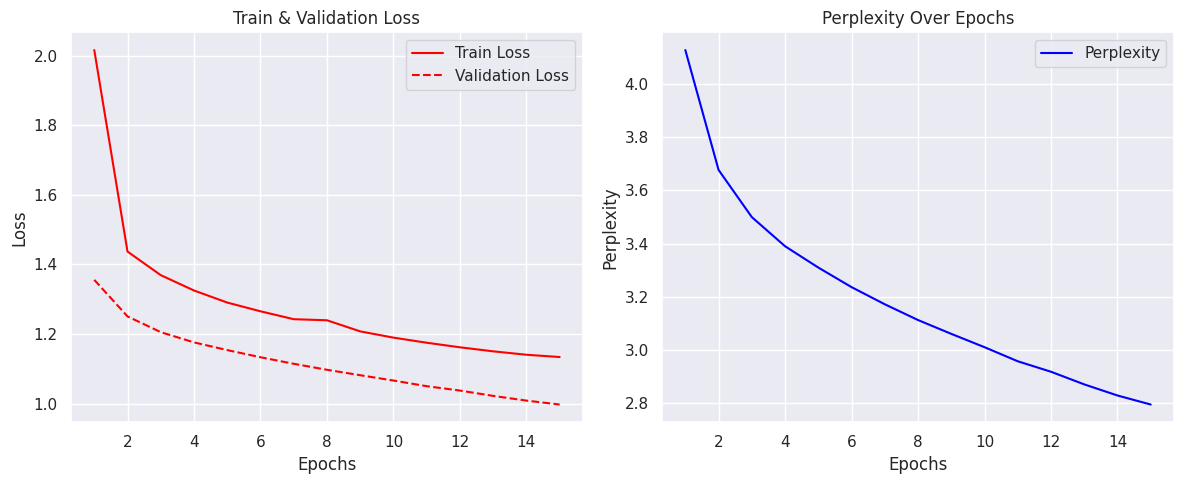

In [ ]:
plot_loss_and_perplexity(train_losses, val_losses, perplexities)

Метрики уверенно улучшаются, нужно продолжать обучение.

К сожалению, вычислительные ресурсы не позволят продолжать обучение.

In [ ]:
val_ppl = evaluate(model, criterion, eval_dataloader)
test_ppl = evaluate(model, criterion, test_dataloader)
print(f"\nPerplexity:\n Val: {val_ppl:.2f} Test: {test_ppl:.2f}")


Perplexity:
 Val: 2.80 Test: 2.83


### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

Проведены следующие эксперименты:

1. Базовая рекурентная модель
2. Рекурентная модель с attention

Модели показали следующее качество:
* Базовая - PPL Val: 4.67 Test: 4.68
* Attention - PPL Val: 2.80 Test: 2.83

Результаты показали, что модель с attention дает качество значительно лучше, но требует значительно больше вычислений.

Модель с attention не получилось обучить до конца в виду вычислительных ограничений.

Что можно улучшить далее:
* Mutihead attention
* Движение в сторону архитектуры трансформер